In [2]:
# ============================================================
# Notebook setup
# ============================================================

%load_ext autoreload
%autoreload 2

# Retrain or use existing models
use_cached_weights = True

# Control figure size
figsize=(14, 3.5)
figsize_narrow=(14, 2.5)

from util import util
import warnings
warnings.filterwarnings("ignore", ".*Consider increasing the value of the `num_workers` argument.*")
warnings.filterwarnings("ignore", ".*GPU available but not used.*")
warnings.filterwarnings("ignore", ".*Previous log files in this directory will be deleted when the new ones are saved!.*")
warnings.filterwarnings("ignore", ".*Checkpoint directory.*exists and is not empty.*")


# Generate a problem instance
nitems, rel_req, seed = 20, 0.5, 42
prb = util.generate_problem(nitems=nitems, rel_req=rel_req, seed=seed)

# Generate basic dataset
data_tr = util.generate_costs(nsamples=350, nitems=nitems, seed=seed, noise_scale=0.1, noise_type='normal', noise_scale_type='absolute')
data_ts = util.generate_costs(nsamples=150, nitems=nitems, seed=seed, sampling_seed=seed+1, noise_scale=0.1, noise_type='normal', noise_scale_type='absolute')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Applicability of DFL

## Let's Second-Guess Ourselvers

**However, let's not discount the prediction-focused approach yet**

In fact, it's easy to see that:

$$
\mathbb{E}[\text{regret}(y, \hat{y})] \xrightarrow[\mathbb{E}\lbrack L(y, \hat{y}) \rbrack \to 0]{} 0
$$

Intuitively:

* The more accurate we can be, the lower the regret
* Eventually, perfect predictions will result in 0 regret

**Overall:**

* If our model is expressive enough (i.e. the model is _not misspecified_)
* ...And the problem is _deterministic_

Then the benefits of DFL will be _vanishingly small_

## Let's Second-Guess Ourselves

**But it gets worse! Let's check again our decision problem:**

$$
z^*(\hat{y}) = \text{argmin}_z \left\{ \hat{y}^T z \mid z \in F \right\}
$$

Under this assumption we have that:
$$\begin{align}
\mathrm{E}_{x,y \sim P(X, Y)}[ \text{regret}(y, \hat{y}) ]
& = \mathrm{E}_{x,y \sim P(X, Y)}[ y^T (z^*(\hat{y}) - z^*(y))] \\
& = \mathrm{E}_{x \sim P(X)}[ {\color{red} \mathrm{E}_{y \sim P(Y \mid x)} [y^T]} (z^*(\hat{y}) - z^*(y)) ]
\end{align}$$

* ...Which means that, if we can accurately predict the $y$ expectation
* ...Then we will be able to make provably optimal decisions

**As long as only _the coefficient of a linear cost_ are uncertain**

...Then the DFL advantage will also be vanishingly small!

## Our Baseline

**Let's check again the results for our PFL linear regressor**

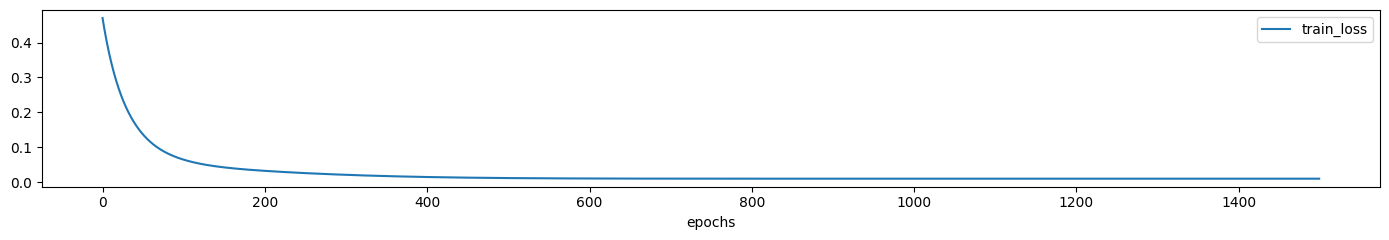

training time: 9.5323
R2: 0.829, MAE: 0.081, RMSE: 0.099 (training)
R2: 0.823, MAE: 0.083, RMSE: 0.101 (test)


In [3]:
pfl = util.TwoPhaseModel(input_size=1, output_size=nitems, hidden_sizes=[], name='pfl')
pfl, history, metadata = util.train_ml_model(pfl, data_tr.index.values.reshape(-1, 1), data_tr.values, epochs=1500, load_cached=use_cached_weights, enable_progress_bar=False, accelerator='cpu')
util.plot_training_history(history, metadata=metadata, figsize=figsize_narrow, print_scores=False)
util.print_ml_metrics(pfl, data_tr.index.values.reshape(-1, 1), data_tr.values, label='training')
util.print_ml_metrics(pfl, data_ts.index.values.reshape(-1, 1), data_ts.values, label='test')

This will be our main baseline

## PFL Strikes Back

**Let's try to use _a non-linear model_**

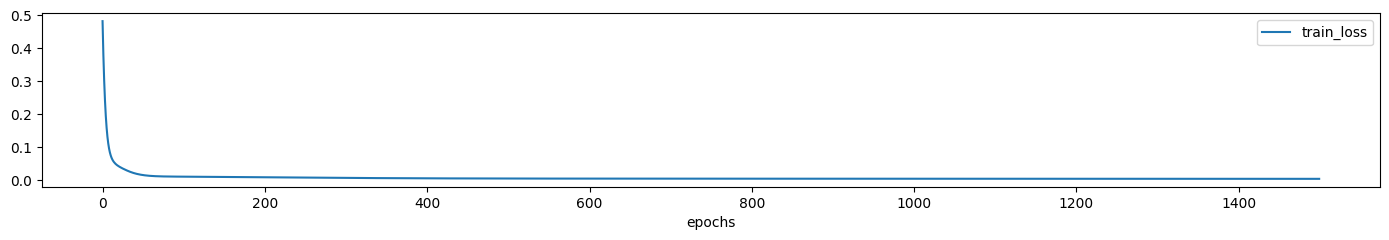

training time: 10.8216
R2: 0.953, MAE: 0.040, RMSE: 0.053 (training)
R2: 0.952, MAE: 0.040, RMSE: 0.054 (test)


In [4]:
pfl_nl = util.TwoPhaseModel(input_size=1, output_size=nitems, hidden_sizes=[16], name='pfl_nl')
pfl_nl, history, metadata = util.train_ml_model(pfl_nl, data_tr.index.values.reshape(-1, 1), data_tr.values, epochs=1500, load_cached=use_cached_weights, enable_progress_bar=False, accelerator='cpu')
util.plot_training_history(history, metadata=metadata, figsize=figsize_narrow, print_scores=False)
util.print_ml_metrics(pfl_nl, data_tr.index.values.reshape(-1, 1), data_tr.values, label='training')
util.print_ml_metrics(pfl_nl, data_ts.index.values.reshape(-1, 1), data_ts.values, label='test')

More accurate, it is!

## PFL Strikes Back

**...And the improvement in terms of regret is remarkable**

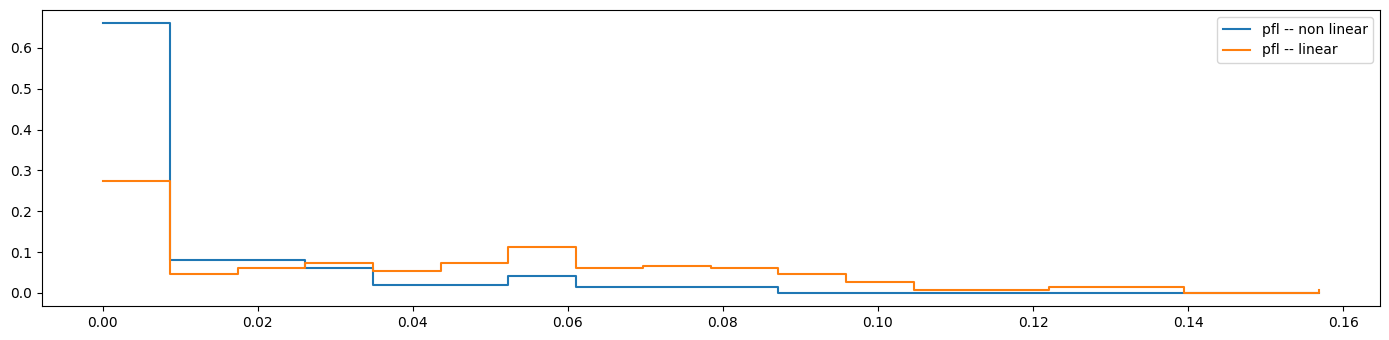

Mean: 0.012 (pfl -- non linear), 0.043 (pfl -- linear)


In [5]:
r_ts = util.compute_regret(prb, pfl, data_ts.index.values.reshape(-1, 1), data_ts.values)
r_ts_nl = util.compute_regret(prb, pfl_nl, data_ts.index.values.reshape(-1, 1), data_ts.values)
util.plot_histogram(r_ts_nl, figsize=figsize, label='pfl -- non linear', data2=r_ts, label2='pfl -- linear', print_mean=True);

## PFL Strikes Back

**Let's what DFL could do with the same model complexity**

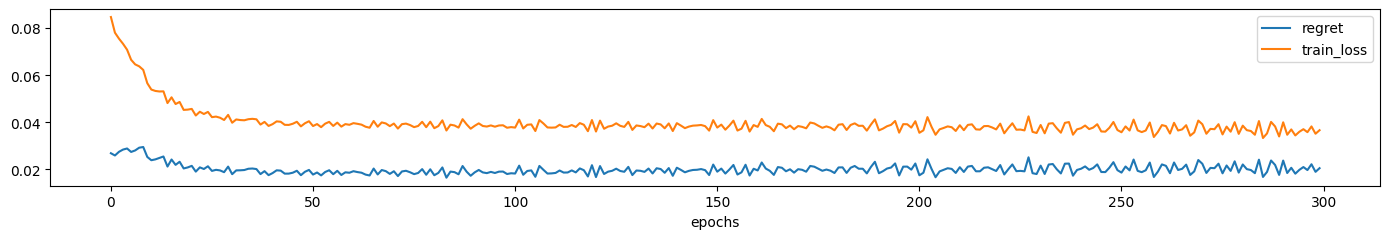

training time: 79.5560
R2: 0.874, MAE: 0.067, RMSE: 0.085 (training)
R2: 0.870, MAE: 0.068, RMSE: 0.086 (test)


In [6]:
spo_nl = util.DFLModel(input_size=1, output_size=nitems, hidden_sizes=[16], problem=prb, name='spo_nl', warm_start_state_dict=pfl_nl.state_dict(), lr=1e-4)
spo_nl, history, metadata = util.train_ml_model(spo_nl, data_tr.index.values.reshape(-1, 1), data_tr.values, epochs=300, load_cached=use_cached_weights, enable_progress_bar=False, accelerator='cpu')
util.plot_training_history(history, metadata=metadata, figsize=figsize_narrow, print_scores=False)
util.print_ml_metrics(spo_nl, data_tr.index.values.reshape(-1, 1), data_tr.values, label='training')
util.print_ml_metrics(spo_nl, data_ts.index.values.reshape(-1, 1), data_ts.values, label='test')

## PFL Strikes Back

**The gap between the approach is closed, or even inverted**

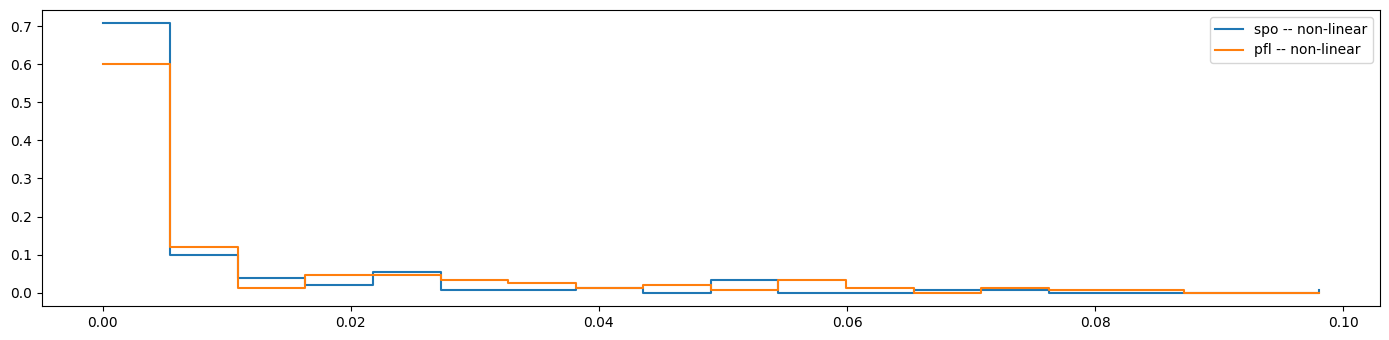

Mean: 0.008 (spo -- non-linear), 0.012 (pfl -- non-linear)


In [7]:
r_ts_spo_nl = util.compute_regret(prb, spo_nl, data_ts.index.values.reshape(-1,1), data_ts.values)
fig = util.plot_histogram(r_ts_spo_nl, figsize=figsize, label='spo -- non-linear', data2=r_ts_nl, label2='pfl -- non-linear', print_mean=True)

## Reflecting on What we Have

**It's worth now reassessing our current situation**

When we have just a _linear cost_ with _uncertain coefficients_:

* If the predictive model is _misaligned_, DFL can provide a benefit
* Otherwise, PFL is faster and leads to the same (or better) decisions

**This is still useful!**

* We can use DFL to _do more with simpler models_
* ...And get better explainability, easier analysis, etc.

**...But if we wish for consistent benefits, we need to _relax our assumptions_**

* For example, we can allow for _non-linear cost functions_
* ...And we are about to see one very common case when they arise

## Two-Stage Stochastic Optimization

**We will focus on two-stage stochastic optimization problems**

Let's consider the problem of packing up for a trip

<center><img src="assets/holiday-suitcase.jpg" width=45%></center>

* Before the trip (_first stage_) we decide what to put in our suitcase
* During the trip (_second stage_), we may realize we have forgotten something
* ...And we need to _spend money_ (_recourse action_) to buy the missing stuff

## Two-Stage Stochastic Optimization

**Two-stage stochastic optimization problems (2s-SOP) are defined as:**

$$
\text{argmin}_{z} \left\{f(z) + \mathbb{E}_{y \sim P(Y \mid x)} \left[\min_{z^"} r(z^", z, y)\right]  \mid z \in F, z^" \in F^"(z, y) \right\}
$$

* $Y$ represents the uncertain information
* $z$ is the vector of _first stage decisions_
* $F$ is the feasible space for the first stage
* $z^"$ is the vector of _recourse actions_
* $z^"$ is not fixed: it can change for every sampled $y$
* The set of feasible recourse actions $F^"(z, y)$ also changes for every $y$
* $f$ is the immediate cost function, $r$ is the cost of the recourse actions

## A Simple Example

**We will consider this simple problem, based on our supply planning example:**

$$\begin{align}
\text{argmin}_{z}\ & c^T z + \mathbb{E}_{y \sim P(Y \mid x)} \left[\min_{z^"} c^" z^" \right] \\
\text{subject to: } & \hat{y}^T z + z^" \geq y_{min} \\
             & z \in \{0,1\}^n, z^" \in \mathbb{N}_0
\end{align}$$

* $z_j = 1$ iff we choose then $h$-th supply contract
* $c_j$ is the cost of the $j$-th contract
* $y_j$ is the yield of the $j$-th contract, which is uncertain
* $y_{min}$ is the minimum total yield, which is known
* $z^"$ is the number of units we buy at cost $c^"$ to satisfy the yield  requirement

Non-linearities in the cost arise here due to the recourse actions

## Scenario Based Approach

**Classical solution approaches for 2s-SOP are _scenario based_**

We start by estimating $P(Y \mid x)$ and sampling a set of $N$ values:

$$\begin{align}
\text{argmin}_{z} \text{min}_{z^"}\ &  c^T z + \frac{1}{N} \sum_{k=1}^N c^" z^"_k \\
\text{subject to: } & y^T z + z^"_k \geq y_{min} & \forall k = 1..N\\
             & z \in \{0,1\}^n \\
             & z^"_k \in \mathbb{N}_0 & \forall k = 1..N
\end{align}$$

Then we build different recourse action variables for each scenario

* ...We define the feasible sets via constraints
* ...And we use the Sample Average Approximation to estimate the expectation

**The method is effective, but also _very computationally expensive_**

## ...And Deterministic Approximations

**Hence, _deterministic approximations_ are very common in practice**

Typically, one optimizes for the _most likely_ scenario:

$$\begin{align}
z^*(y) = \text{argmin}_{z} \text{min}_{z^"} &  c^T z + c^" z^"_k \\
\text{subject to: } & y^T z + z^"_k \geq y_{min} &\\
             & z \in \{0,1\}^n \\
             & z^"_k \in \mathbb{N}_0 &
\end{align}$$

By doing this:

* The scalability is comparable with 1-stage problems
* We can obtain the scenario via a classic predictor (point estimator)
* ...But we no longer properly account for uncertainty

## DFL for 2s-SOP

**We can use DFL principles to address problems in this class**

Intuitively, the approach works as follows

* We observe $x$ and we compute $\hat{y}$
* We compute $z^*(\hat{y})$ by solving a single-scenario problem
* We compute $\text{regret}(y, \hat{y})$ by solving a single-scenario problem with fixed $z$

**By doing this:**

...We end up solving a problem very close to 2s-SOP

* We will have a couple of limitations
* ...But also several major advantages

## DFL for 2s-SOP

**To get there, we'll need to adjust a bit our formulation**

In particular, we'll consider a  _single-scenario 2s-SOP_:

$$
z^*(y) = \text{argmin}_z \{ f(z) + r(z'', z, y) \mid z \in F, z'' \in F''(z, y) \}
$$

...And the _post-hoc cost_ evaluation function:

$$
g(z, y) = \min_{z''} \{f(z) + f(z'', z, y) \mid z'' \in F''(z, y)\}
$$

I.e. the cost of the first-stage decision $z$ under scenario $y$

* The first problem is a more general version of those used in classic DFL
* The second function is new

## DFL for 2s-SOP

**Then we can formulate this generalized DFL training problem**

$$
\text{argmin}_\theta \mathrm{E}_{x, y \sim P(X, Y)}[g(z^*(\hat{y}, y)) - g(z, y)]
$$

* where $g(z^*(\hat{y}, y)) - g(z, y)$ is called _post-hoc regret_
* ...or _value of perfect information_

**For a given input $x$, this reduces to:**

$$\begin{align}
& \text{argmin}_\theta \mathrm{E}_{y \sim P(Y \mid x)} [g(z^*(\hat{y}, y)) - g(z, y)] = \\ 
& \qquad \text{argmin}_\theta \mathrm{E}_{y \sim P(Y \mid x)} [g(z^*(\hat{y}, y))]
\end{align}$$

where the right-end terms is very close to the classic 2s-SOP objective

## Overview and Properties

**Overall:**

We only solve _single-scenario problems_

* This is true both at training and inference time
* ...And leads to massively better scalability than scenario-based methods

We can use a point estimator

* There's no need to estimate $P(Y \mid x)$
* ...Which might entail guessing the correct distribution type

However:

* Sometimes, using a single scenario [is not enough](https://arxiv.org/abs/2505.03953)
* ...And we are generating the scenario indirectly, by adjusting $\theta$